# AG-HYPOPT · Trial 20

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nineteen trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The `cvm_fwhm` series (nine points,
sw 0.18-0.38) has mean ~0.0781 with scatter up to 0.084 (trial_19 was the first draw above the KDE control
0.080328), so the family's edge is small (~0.002 on the mean) but broadly consistent in sign. All other
families at matched sw are clearly above the control. The win is a gamma-channel, loss-FORM effect.
Remaining trials refine the winner. No divergences. Phase `trials` (19/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_20'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (19/5 trials)
ID |     ei | params
 1 | 2.0760 | {"loss_family": "mmd_2d", "sigma_weight": 0.20770518282473927}
 2 | 3.1674 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19138618132191307}
 3 | 2.2303 | {"loss_family": "w1_2d", "sigma_weight": 0.19603173413451686}
 4 | 2.0286 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2085621085031748}
 5 | 0.3292 | {"loss_family": "mmd_2d", "sigma_weight": 0.05258557112249318}
 6 | 2.5460 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2346705805097604}
 7 | 0.0995 | {"loss_family": "mmd_2d", "sigma_weight": 0.4679469077894437}
 8 | 3.1775 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20781023901379525}
 9 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.6129694059842482}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.4674253576456282}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI again leads with `cvm_fwhm`, now at sw 0.2078 (candidate 8, ei 3.1775) with candidate 2 (sw 0.1914,
ei 3.1674) just behind. Both are central-basin points and would add independent draws to the family's
statistics - which trial_19 showed are wider than first thought, so more draws genuinely help to pin the
mean margin over the control. I take the top-EI candidate 8. The remaining candidates are non-`cvm_fwhm`
families already known to be worse.

I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.20781023901379525}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.54 | γ 8.5 -> 5.94 | NLL 0.84


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.59 | γ 14.1 -> 13.86 | NLL 0.11


Running 3nW Trans100 ... 

μ 175.71 -> 93.80 | γ 14.1 -> 13.53 | NLL 16.60



Total: 7.8 min


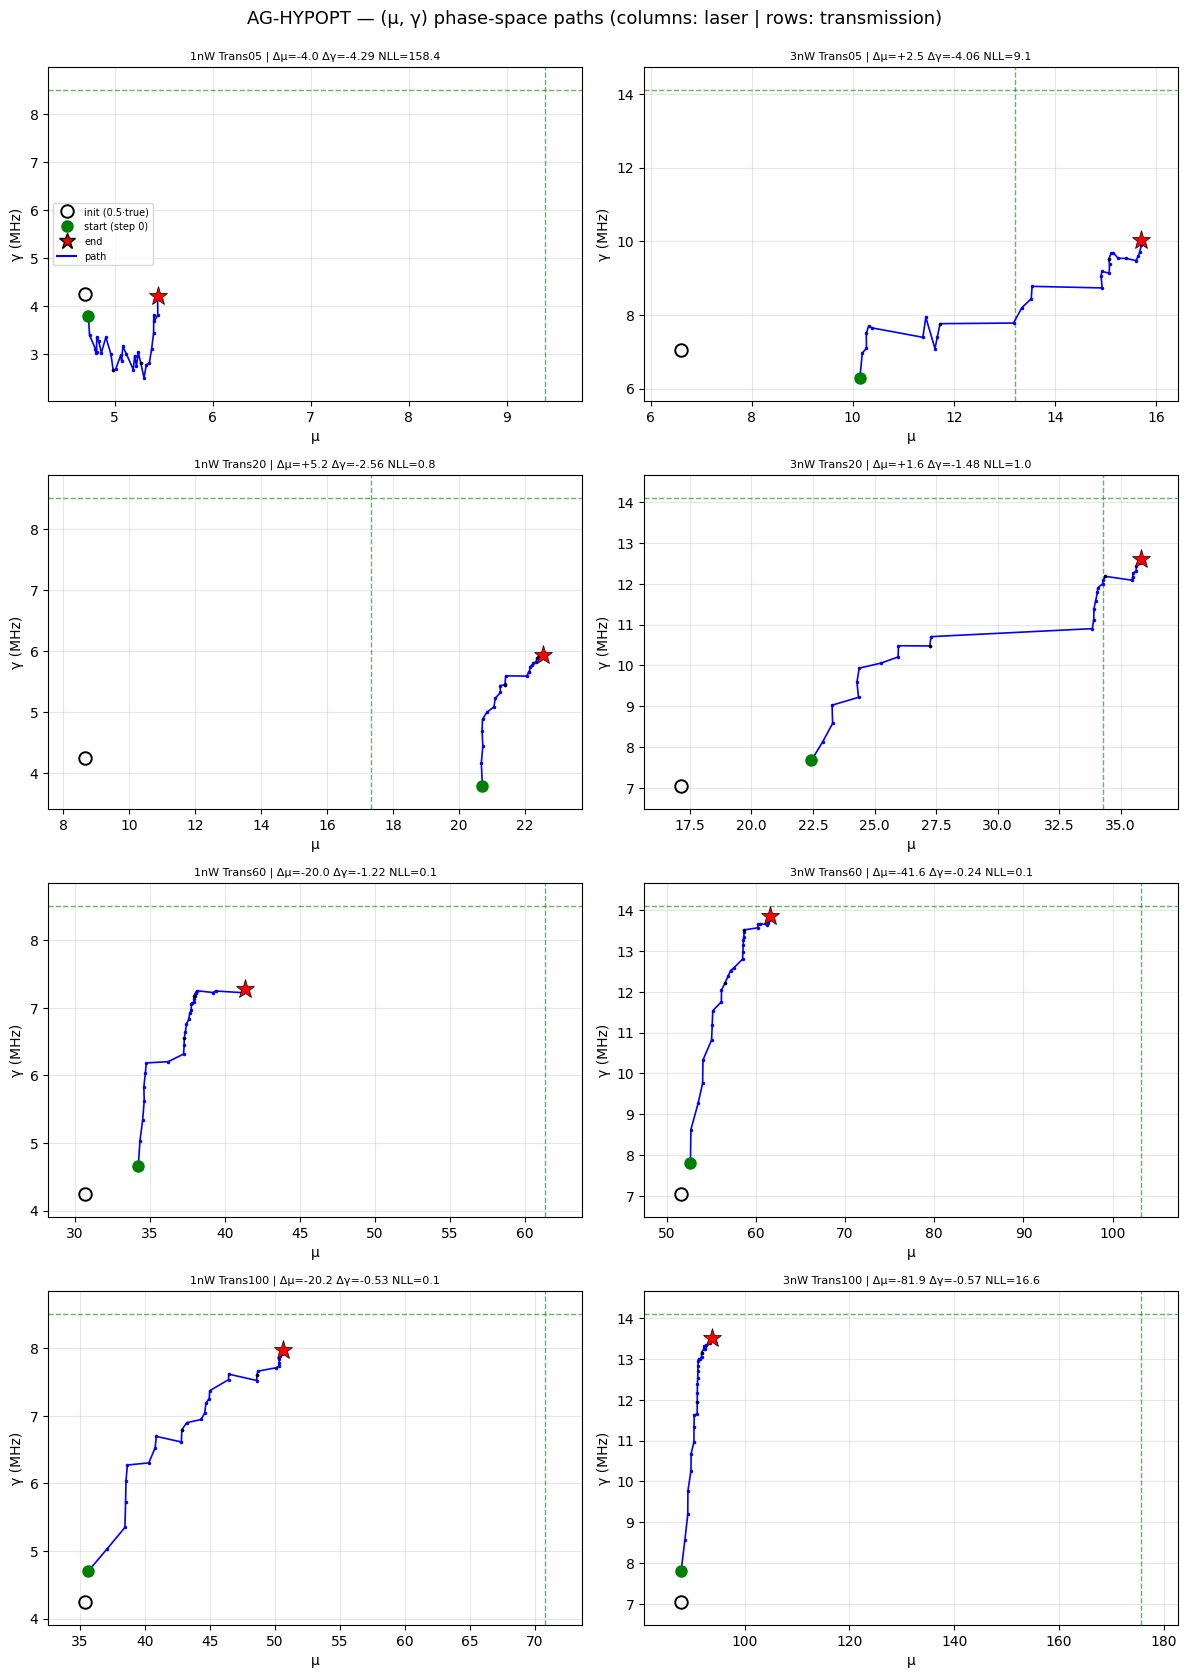

trial finished in 7.8 min
objective = 0.0778 ± 0.0205
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.54   +30.2 |     8.50    5.94   -30.1
1nW Trans60       61.37   41.35   -32.6 |     8.50    7.28   -14.3
1nW Trans100       70.82   50.63   -28.5 |     8.50    7.97    -6.2
3nW Trans05       13.20   15.70   +18.9 |    14.10   10.04   -28.8
3nW Trans20       34.28   35.83    +4.5 |    14.10   12.62   -10.5
3nW Trans60      103.20   61.59   -40.3 |    14.10   13.86    -1.7
3nW Trans100      175.71   93.80   -46.6 |    14.10   13.53    -4.1

weighted objective (T-graded, cap=1.0) = 0.0778 | diverged cells: 0
μ: RMSE 34.096 (rel 33.0%, bias -19.801) | γ: RMSE 2.393 (rel 24.1%, bias -1.869)


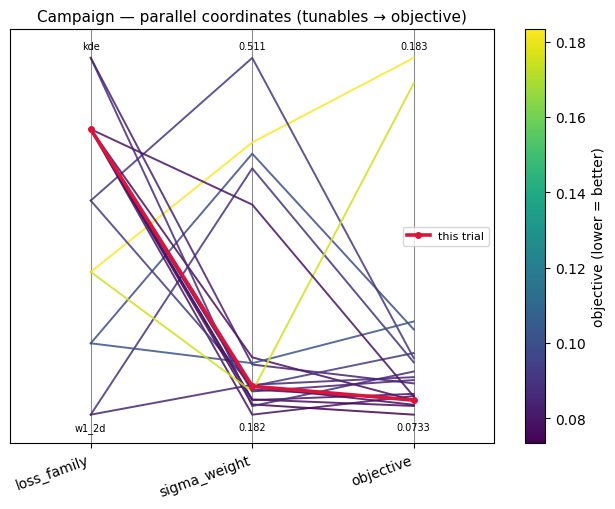

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.2078}` (candidate 8, top EI).
Trial time 7.8 min, objective **0.0778 +/- 0.0205**, **0 diverged cells** - a basin replication.

**Basin statistics.** The `cvm_fwhm` series now has ten points over sw 0.18-0.38: 0.0733, 0.0760, 0.0764,
0.0777, 0.0778, 0.0781, 0.0790, 0.0791, 0.0798, 0.0840 -> mean ~0.0781, std ~0.003, with nine of ten
under the KDE control (0.080328) and one (trial_19) just above.

**Per-cell behaviour.** Low-count cells unchanged (1nW Trans05 mu 5.44 / gamma 4.21); high-T mu low
(-29 to -47 %), gamma fine (-1.7 % to -6.2 %).

**Aggregates.** mu: RMSE 34.10 (rel 33.0 %), bias -19.80; gamma: RMSE 2.39 (rel 24.1 %), bias -1.87.

**Summary:** `cvm_fwhm` at sw 0.2078 gives 0.0778, another basin replication bringing the family mean to
~0.0781 over ten draws, nine of which are under the KDE control.
**Key insight:** The `cvm_fwhm` mean (~0.0781) sits ~0.002 under the control, a small but mostly
consistent margin; the held-out set is what will decide its significance.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.2078 gives 0.0778, another basin replication bringing the family mean to ~0.0781 over ten draws, nine of which are under the KDE control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm mean (~0.0781) sits ~0.002 under the control, a small but mostly consistent margin; the held-out set will decide its significance.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_20 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_21.ipynb. Open it and follow its cells from the top.
